In [3]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)
print("Directories ready")
print(f"Current working directory: {os.getcwd()}")

PyTorch version: 2.12.1+cu130
CUDA available: False
Directories ready
Current working directory: /home/jonny/Desktop/Code/Hackathons/Qualcomm/vigilant_cascade/notebooks


In [4]:
# Cell 2: Load data
# Paths relative to notebooks folder
DATA_PATH = '../data/'

normal_df = pd.read_csv(f'{DATA_PATH}normal3.csv', header=None, names=['raw', 'baseline', 'delta', 'current'])
slowed_df = pd.read_csv(f'{DATA_PATH}slowed3.csv', header=None, names=['raw', 'baseline', 'delta', 'current'])

print("="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"Normal data shape: {normal_df.shape}")
print(f"Slowed data shape: {slowed_df.shape}")
print("\nNormal data sample:")
print(normal_df.head())
print("\nSlowed data sample:")
print(slowed_df.head())

print("\nNormal data stats:")
print(normal_df['current'].describe())
print("\nSlowed data stats:")
print(slowed_df['current'].describe())

DATA OVERVIEW
Normal data shape: (1280, 4)
Slowed data shape: (1280, 4)

Normal data sample:
        raw  baseline  delta  current
0  49433208     49433    0.0     0.91
1  49495716     49495    0.0     5.05
2  49556118     49556    0.0     0.83
3  49617515     49617    0.0     6.04
4  49675516     49675    0.0     4.57

Slowed data sample:
        raw  baseline  delta  current
0  20347608     20347    0.0     6.20
1  20410920     20410    0.0     5.04
2  20470016     20470    0.0     2.82
3  20531226     20531    0.0     7.51
4  20590326     20590    0.0     7.43

Normal data stats:
count    1280.000000
mean        4.059477
std         2.333121
min        -0.100000
25%         1.697500
50%         4.780000
75%         6.040000
max         8.130000
Name: current, dtype: float64

Slowed data stats:
count    1280.00000
mean        9.31150
std         3.69592
min         0.42000
25%         6.51000
50%         9.63500
75%        12.20250
max        18.73000
Name: current, dtype: float64


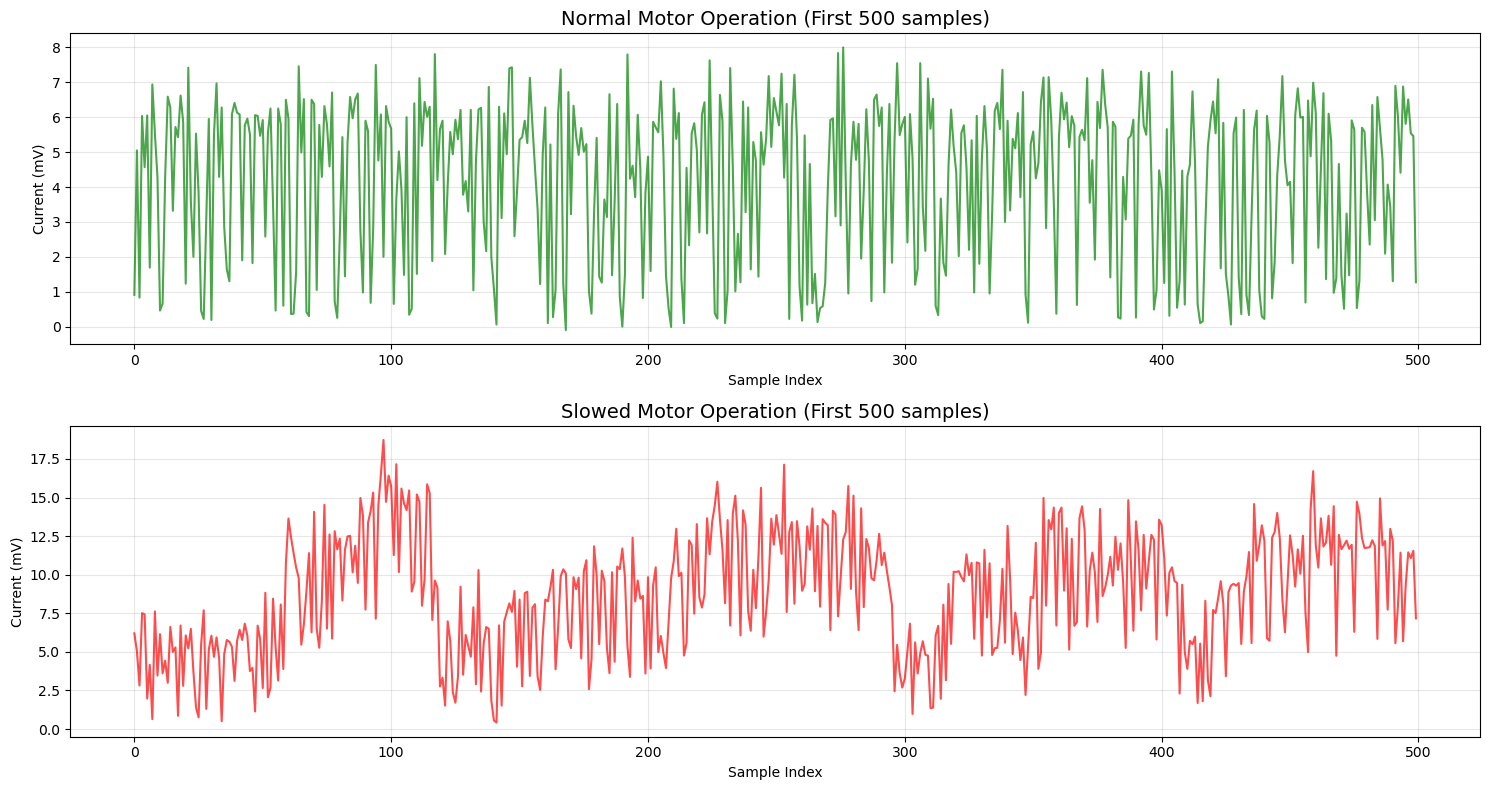

In [5]:
# Cell 3: Visualize the time series data
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Plot first 500 samples of normal data
axes[0].plot(normal_df['current'].values[:500], color='green', alpha=0.7)
axes[0].set_title('Normal Motor Operation (First 500 samples)', fontsize=14)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Current (mV)')
axes[0].grid(True, alpha=0.3)

# Plot first 500 samples of slowed data
axes[1].plot(slowed_df['current'].values[:500], color='red', alpha=0.7)
axes[1].set_title('Slowed Motor Operation (First 500 samples)', fontsize=14)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Current (mV)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/data_exploration.png', dpi=150)
plt.show()

In [6]:
# Cell 4: Create sliding windows
WINDOW_SIZE = 128

def create_windows(data, window_size):
    """Create sliding windows from time series data"""
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i:i+window_size])
    return np.array(windows)

# Extract current values
normal_data = normal_df['current'].values
slowed_data = slowed_df['current'].values

# Create windows
normal_windows = create_windows(normal_data, WINDOW_SIZE)
slowed_windows = create_windows(slowed_data, WINDOW_SIZE)

print("="*60)
print("WINDOW CREATION RESULTS")
print("="*60)
print(f"Normal windows: {normal_windows.shape}")
print(f"Slowed windows: {slowed_windows.shape}")

# Combine and create labels
X = np.vstack([normal_windows, slowed_windows])
y = np.hstack([np.zeros(len(normal_windows)), np.ones(len(slowed_windows))])

print(f"\nTotal samples: {X.shape[0]}")
print(f"Features per sample: {X.shape[1]}")
print(f"Class distribution:")
print(f"  Normal (0): {np.sum(y == 0)} samples")
print(f"  Slowed (1): {np.sum(y == 1)} samples")

# Shuffle
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

WINDOW CREATION RESULTS
Normal windows: (1153, 128)
Slowed windows: (1153, 128)

Total samples: 2306
Features per sample: 128
Class distribution:
  Normal (0): 1153 samples
  Slowed (1): 1153 samples


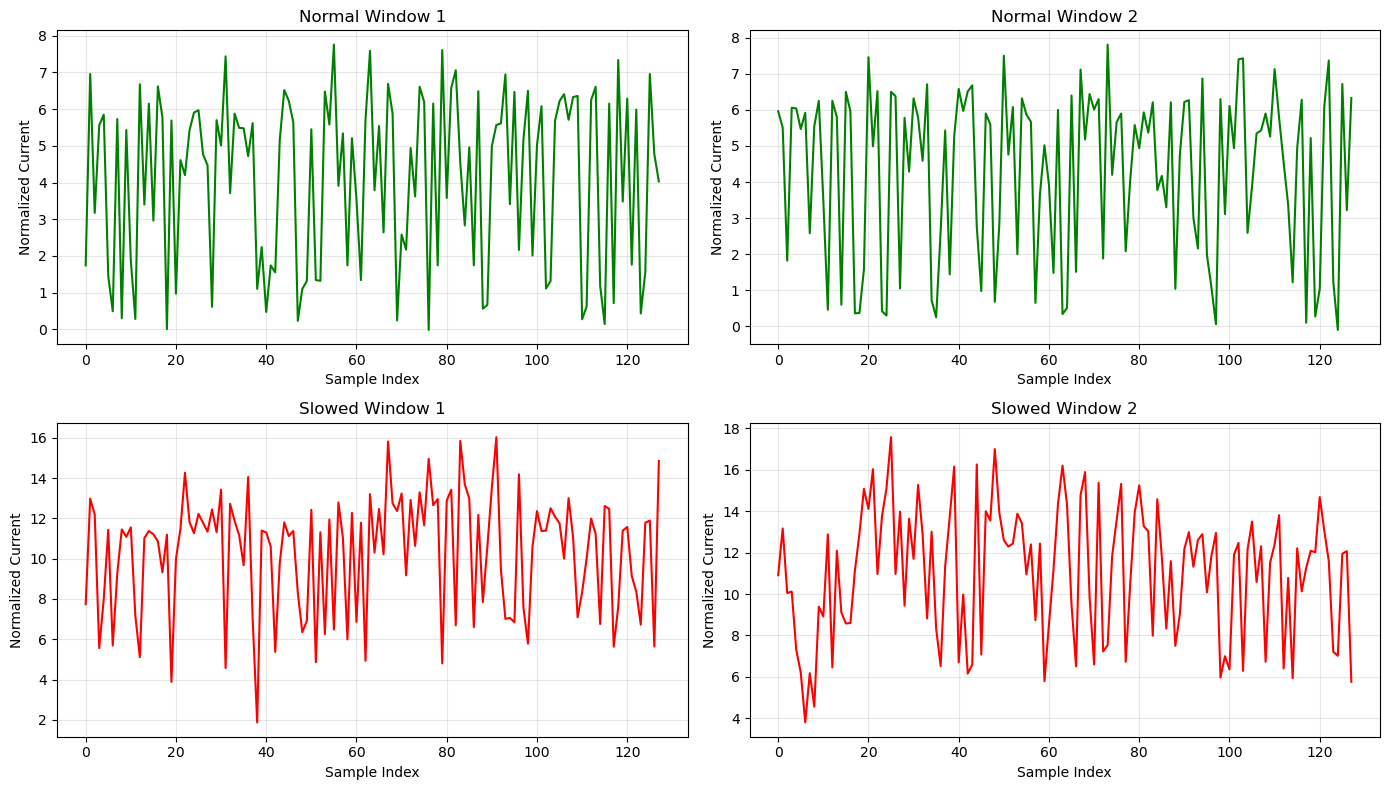

In [7]:
# Cell 5: Visualize sample windows
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot 2 normal windows
normal_samples = np.where(y == 0)[0][:2]
for i, idx in enumerate(normal_samples):
    axes[0, i].plot(X[idx], color='green')
    axes[0, i].set_title(f'Normal Window {i+1}')
    axes[0, i].set_xlabel('Sample Index')
    axes[0, i].set_ylabel('Normalized Current')
    axes[0, i].grid(True, alpha=0.3)

# Plot 2 slowed windows
slowed_samples = np.where(y == 1)[0][:2]
for i, idx in enumerate(slowed_samples):
    axes[1, i].plot(X[idx], color='red')
    axes[1, i].set_title(f'Slowed Window {i+1}')
    axes[1, i].set_xlabel('Sample Index')
    axes[1, i].set_ylabel('Normalized Current')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/sample_windows.png', dpi=150)
plt.show()

In [8]:
# Cell 6: Normalize and split data
# Normalize the data
scaler = MinMaxScaler()
X_reshaped = X.reshape(-1, 1)
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(-1, WINDOW_SIZE)

# Save scaler for later use
joblib.dump(scaler, '../models/scaler.joblib')
print("Scaler saved to ../models/scaler.joblib")

# Split data
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("\n" + "="*60)
print("DATA SPLIT RESULTS")
print("="*60)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining set - Class distribution:")
print(f"  Normal (0): {np.sum(y_train == 0)}")
print(f"  Slowed (1): {np.sum(y_train == 1)}")

✅ Scaler saved to ../models/scaler.joblib

DATA SPLIT RESULTS
Training set: 1613 samples
Validation set: 231 samples
Test set: 462 samples

Training set - Class distribution:
  Normal (0): 806
  Slowed (1): 807


In [9]:
# Cell 7: Define the CNN model
class MotorFaultCNN(nn.Module):
    """1D CNN for motor fault detection"""
    def __init__(self, input_length=128):
        super(MotorFaultCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv1d(1, 32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.15)
        
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)
        self.dropout2 = nn.Dropout(0.2)
        
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(2)
        self.dropout3 = nn.Dropout(0.3)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 16, 64)  # After 3 pools: 128/8 = 16
        self.bn_fc1 = nn.BatchNorm1d(64)
        self.dropout_fc = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, 2)
        
    def forward(self, x):
        # Conv block 1
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout1(x)
        
        # Conv block 2
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout2(x)
        
        # Conv block 3
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout3(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        
        return x

# Create model and show architecture
model = MotorFaultCNN()
print("="*60)
print("MODEL ARCHITECTURE")
print("="*60)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MODEL ARCHITECTURE
MotorFaultCNN(
  (conv1): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.15, inplace=False)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.2, inplace=False)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=64, bias=True)

In [10]:
# Cell 8: Create PyTorch DataLoaders
BATCH_SIZE = 32

# Convert to tensors and add channel dimension
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 51
Validation batches: 8
Test batches: 15


In [11]:
# Cell 9: Training function with early stopping
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    """Train the model"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    # Tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    best_val_acc = 0
    patience = 15
    patience_counter = 0
    
    print(f"\n{'='*60}")
    print(f"TRAINING STARTED")
    print(f"Device: {device}")
    print(f"Epochs: {epochs}")
    print(f"Learning rate: {lr}")
    print(f"{'='*60}\n")
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
        
        train_acc = 100 * train_correct / train_total
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()
        
        val_acc = 100 * val_correct / val_total
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_acc)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Print progress
        print(f'Epoch {epoch+1:3d}/{epochs}:')
        print(f'  Train Loss: {history["train_loss"][-1]:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Val Loss: {history["val_loss"][-1]:.4f}, Val Acc: {val_acc:.2f}%')
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), '../models/best_model.pth')
            print(f'  *** Best model saved! (Val Acc: {val_acc:.2f}%) ***')
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= patience:
            print(f'  Early stopping triggered at epoch {epoch+1}')
            break
    
    # Load best model
    model.load_state_dict(torch.load('../models/best_model.pth'))
    print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.2f}%")
    
    return model, history

In [12]:
# Cell 10: Run training
# Train
model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.001
)


TRAINING STARTED
Device: cpu
Epochs: 50
Learning rate: 0.001

Epoch   1/50:
  Train Loss: 0.0824, Train Acc: 98.45%
  Val Loss: 0.0505, Val Acc: 100.00%
  *** Best model saved! (Val Acc: 100.00%) ***
Epoch   2/50:
  Train Loss: 0.0330, Train Acc: 99.75%
  Val Loss: 0.0031, Val Acc: 100.00%
Epoch   3/50:
  Train Loss: 0.0151, Train Acc: 99.88%
  Val Loss: 0.0134, Val Acc: 100.00%
Epoch   4/50:
  Train Loss: 0.0071, Train Acc: 100.00%
  Val Loss: 0.0038, Val Acc: 100.00%
Epoch   5/50:
  Train Loss: 0.0066, Train Acc: 99.94%
  Val Loss: 0.0010, Val Acc: 100.00%
Epoch   6/50:
  Train Loss: 0.0032, Train Acc: 100.00%
  Val Loss: 0.0015, Val Acc: 100.00%
Epoch   7/50:
  Train Loss: 0.0031, Train Acc: 100.00%
  Val Loss: 0.0008, Val Acc: 100.00%
Epoch   8/50:
  Train Loss: 0.0018, Train Acc: 100.00%
  Val Loss: 0.0007, Val Acc: 100.00%
Epoch   9/50:
  Train Loss: 0.0017, Train Acc: 100.00%
  Val Loss: 0.0004, Val Acc: 100.00%
Epoch  10/50:
  Train Loss: 0.0012, Train Acc: 100.00%
  Val Loss:

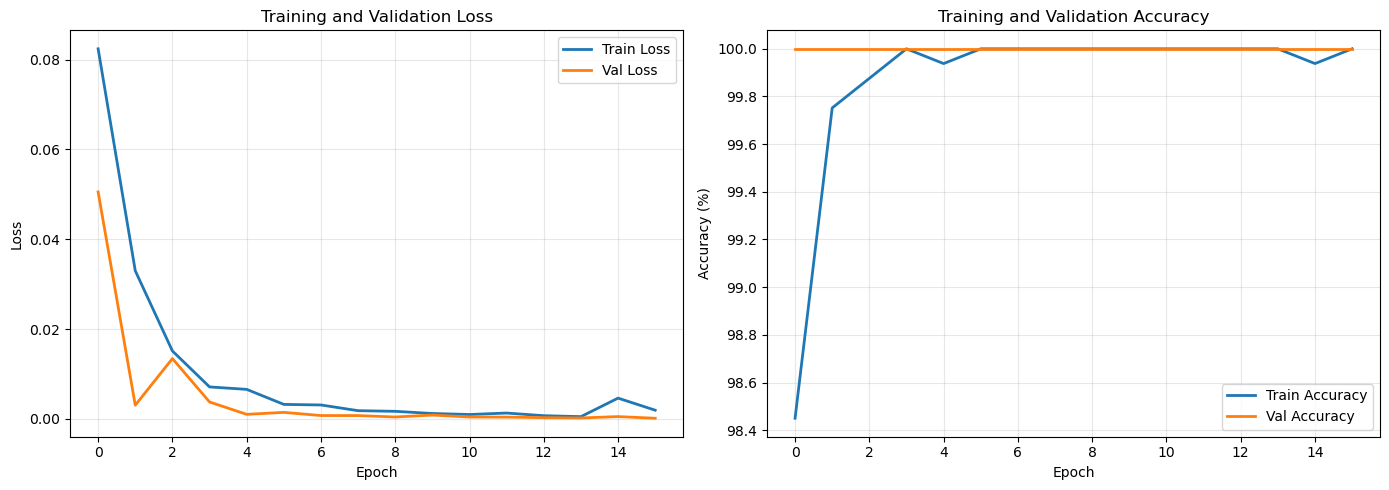

Final training accuracy: 100.00%
Best validation accuracy: 100.00%


In [13]:
# Cell 11: Visualize training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Accuracy', linewidth=2)
ax2.plot(history['val_acc'], label='Val Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/training_history.png', dpi=150)
plt.show()

print(f"Final training accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Best validation accuracy: {max(history['val_acc']):.2f}%")

In [14]:
# Cell 12: Evaluate on test set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.numpy())
        all_probs.extend(probs.cpu().numpy()[:, 1])

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
accuracy = 100 * np.mean(all_preds == all_labels)
cm = confusion_matrix(all_labels, all_preds)

print("="*60)
print("TEST SET EVALUATION")
print("="*60)
print(f"Accuracy: {accuracy:.2f}%")
print(f"Total samples: {len(all_labels)}")
print(f"Class 0 (Normal): {np.sum(all_labels == 0)} samples")
print(f"Class 1 (Slowed): {np.sum(all_labels == 1)} samples")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Slowed']))

TEST SET EVALUATION
Accuracy: 100.00%
Total samples: 462
Class 0 (Normal): 231 samples
Class 1 (Slowed): 231 samples

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       231
      Slowed       1.00      1.00      1.00       231

    accuracy                           1.00       462
   macro avg       1.00      1.00      1.00       462
weighted avg       1.00      1.00      1.00       462



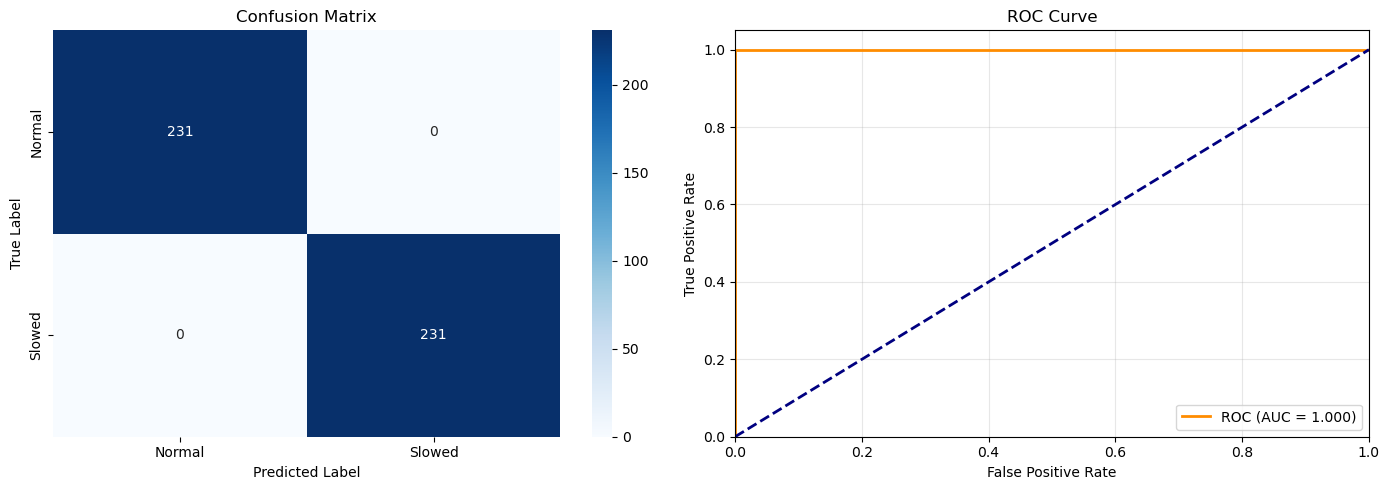

In [15]:
# Cell 13: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Slowed'],
            yticklabels=['Normal', 'Slowed'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/evaluation_metrics.png', dpi=150)
plt.show()

In [16]:
# Cell 14: Export model to ONNX
def export_to_onnx(model, input_length=128):
    """Export model to ONNX format"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    dummy_input = torch.randn(1, 1, input_length).to(device)
    
    onnx_path = "../models/motor_fault_model.onnx"
    torch.onnx.export(
        model,
        dummy_input,
        onnx_path,
        export_params=True,
        opset_version=11,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )
    print(f"Model exported to {onnx_path}")

export_to_onnx(model)

# Show saved files
print("\n" + "="*60)
print("SAVED FILES")
print("="*60)
for file in os.listdir('../models'):
    if os.path.isfile(f'../models/{file}'):
        size = os.path.getsize(f'../models/{file}')
        print(f"  - {file} ({size/1024:.1f} KB)")

W0712 03:47:02.115000 173601 site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MotorFaultCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MotorFaultCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnx/version_converter.py", line 39, in convert_vers

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to ../models/motor_fault_model.onnx

SAVED FILES
  - motor_model.pth (47.1 KB)
  - motor_model_scratch.pth (47.3 KB)
  - motor_model_scratch3.pth (47.3 KB)
  - motor_model.onnx.data (39.6 KB)
  - motor_model.onnx (11.3 KB)
  - data_exploration.png (397.6 KB)
  - sample_windows.png (318.3 KB)
  - scaler.joblib (0.7 KB)
  - best_model.pth (664.5 KB)
  - training_history.png (92.1 KB)
  - evaluation_metrics.png (74.0 KB)
  - motor_fault_model.onnx.data (649.9 KB)
  - motor_fault_model.onnx (16.7 KB)


INFERENCE TEST

Testing NORMAL window:
  Prediction: NORMAL
  Confidence: 0.863

Testing FAULT window:
  Prediction: FAULT
  Confidence: 0.626


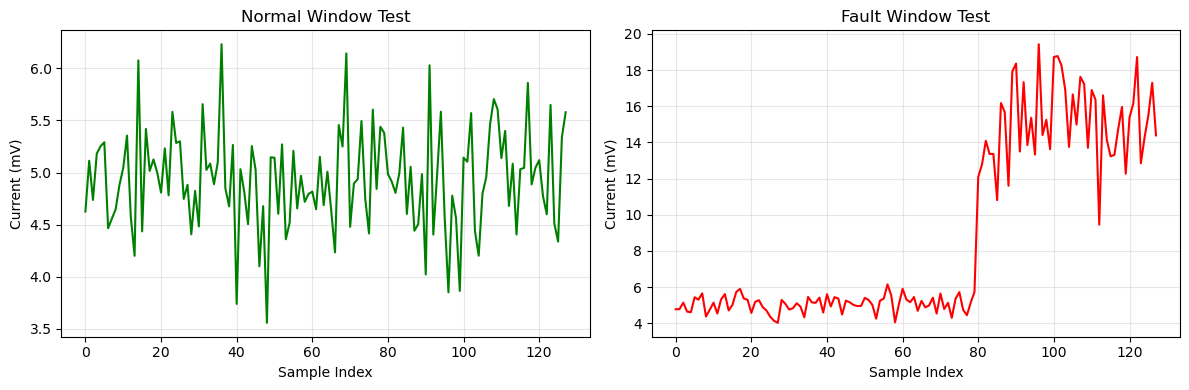

In [17]:
# Cell 15: Test inference on sample data
def test_inference(model, scaler, window_data):
    """Test inference on a single window"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    # Preprocess
    window_reshaped = np.array(window_data).reshape(-1, 1)
    window_scaled = scaler.transform(window_reshaped)
    input_tensor = torch.tensor(window_scaled.reshape(1, 1, -1), dtype=torch.float32).to(device)
    
    # Inference
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()
        confidence = probs[0][pred].item()
    
    is_fault = (pred == 1)
    return {
        'prediction': pred,
        'confidence': confidence,
        'is_fault': is_fault,
        'label': 'FAULT' if is_fault else 'NORMAL'
    }

# Load scaler
scaler = joblib.load('../models/scaler.joblib')

# Create test windows
normal_window = np.random.normal(5.0, 0.5, 128)
fault_window = np.concatenate([
    np.random.normal(5.0, 0.5, 80),
    np.random.normal(15.0, 2.0, 48)
])

# Test
print("="*60)
print("INFERENCE TEST")
print("="*60)

print("\nTesting NORMAL window:")
result = test_inference(model, scaler, normal_window)
print(f"  Prediction: {result['label']}")
print(f"  Confidence: {result['confidence']:.3f}")

print("\nTesting FAULT window:")
result = test_inference(model, scaler, fault_window)
print(f"  Prediction: {result['label']}")
print(f"  Confidence: {result['confidence']:.3f}")

# Visualize the test windows
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(normal_window, color='green')
axes[0].set_title('Normal Window Test')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Current (mV)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(fault_window, color='red')
axes[1].set_title('Fault Window Test')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Current (mV)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Cell 17: Quick inference function for deployment
class MotorFaultDetector:
    def __init__(self, model_path='../models/best_model.pth', scaler_path='../models/scaler.joblib'):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Load model
        self.model = MotorFaultCNN()
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.to(self.device)
        self.model.eval()
        
        # Load scaler
        self.scaler = joblib.load(scaler_path)
        print(f"✅ Model loaded on {self.device}")
    
    def predict(self, window_data):
        """Predict if window is normal or fault"""
        # Preprocess
        window_reshaped = np.array(window_data).reshape(-1, 1)
        window_scaled = self.scaler.transform(window_reshaped)
        input_tensor = torch.tensor(window_scaled.reshape(1, 1, -1), dtype=torch.float32).to(self.device)
        
        # Inference
        with torch.no_grad():
            output = self.model(input_tensor)
            probs = torch.softmax(output, dim=1)
            pred = torch.argmax(output, dim=1).item()
            confidence = probs[0][pred].item()
        
        return {
            'prediction': pred,
            'confidence': confidence,
            'is_fault': (pred == 1),
            'label': 'FAULT' if pred == 1 else 'NORMAL'
        }

# Test the detector
print("Creating detector...")
detector = MotorFaultDetector()

print("\nTesting detector with a fault window:")
result = detector.predict(fault_window)
print(f"  Result: {result['label']} (confidence: {result['confidence']:.3f})")

Creating detector...
✅ Model loaded on cpu

Testing detector with a fault window:
  Result: FAULT (confidence: 0.626)


In [31]:
# Cell 18: Quantize model to TFLite for edge deployment (Fixed verification shape)
import torch
import numpy as np
import joblib
import pandas as pd
import tensorflow as tf
import warnings
import subprocess
import sys
import os
import struct
warnings.filterwarnings('ignore')

def patch_onnx_helper():
    """Dynamically patch missing float32_to_bfloat16 in modern onnx packages"""
    try:
        import onnx.helper
        if not hasattr(onnx.helper, "float32_to_bfloat16"):
            def float32_to_bfloat16(fval):
                ival = struct.unpack("=I", struct.pack("=f", fval))[0]
                return ival >> 16
            onnx.helper.float32_to_bfloat16 = float32_to_bfloat16
    except Exception:
        pass

def create_representative_dataset():
    """Create representative dataset from normal data for quantization"""
    df = pd.read_csv('../data/normal3.csv', header=None, names=['raw', 'baseline', 'delta', 'current'])
    scaler = joblib.load('../models/scaler.joblib')
    
    count = 0
    for i in range(0, min(2000, len(df)), 64):
        window = df['current'].values[i:i+128]
        if len(window) == 128:
            window_scaled = scaler.transform(window.reshape(-1, 1))
            yield [window_scaled.reshape(1, 1, 128).astype(np.float32)]
            count += 1
            if count >= 100:
                break

def verify_tflite_model(tflite_path):
    """Verify the TFLite model loads and runs with correct input shape matching the model"""
    try:
        interpreter = tf.lite.Interpreter(model_path=tflite_path)
        interpreter.allocate_tensors()
        
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()
        
        # Get the actual expected shape from the model details instead of hardcoding a mismatch
        expected_shape = input_details[0]['shape']
        print(f"   Expected input shape from model: {expected_shape}")
        
        test_input = np.random.randn(*expected_shape).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], test_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        
        print(f"   TFLite model verified!")
        print(f"   Input shape: {input_details[0]['shape']}")
        print(f"   Output shape: {output_details[0]['shape']}")
        print(f"   Sample output: {output[0]}")
        
    except Exception as e:
        print(f"   TFLite model verification failed: {e}")

def quantize_to_tflite():
    """Convert PyTorch model to quantized TFLite via ONNX and onnx2tf"""
    print("🚀 Starting quantization...")
    
    # Apply runtime patch for compatibility
    patch_onnx_helper()
    
    # Load model
    model = MotorFaultCNN()
    model.load_state_dict(torch.load('../models/best_model.pth', map_location='cpu'))
    model.eval()
    
    # Export to ONNX
    dummy_input = torch.randn(1, 1, 128)
    onnx_path = "../models/model.onnx"
    
    torch.onnx.export(
        model,
        dummy_input,
        onnx_path,
        export_params=True,
        opset_version=13,
        input_names=['input'],
        output_names=['output']
    )
    print("✅ Exported to ONNX (opset 13)")
    
    # Convert to TensorFlow using onnx2tf
    print("🔄 Converting to TensorFlow using onnx2tf...")
    try:
        import onnx2tf
        import shutil
        
        for path in ["../models/model_tf", "../models/model_tf_quant"]:
            if os.path.exists(path):
                shutil.rmtree(path)
        
        onnx2tf.convert(
            input_onnx_file_path=onnx_path,
            output_folder_path="../models/model_tf",
            output_signaturedefs=True
        )
        print("✅ Converted to TensorFlow using onnx2tf")
        
        saved_model_path = "../models/model_tf/saved_model"
        if not os.path.exists(saved_model_path):
            saved_model_path = "../models/model_tf"
            
        converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = create_representative_dataset
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.float32
        converter.inference_output_type = tf.float32
        
        tflite_model = converter.convert()
        
        tflite_path = "../models/model_quantized.tflite"
        with open(tflite_path, "wb") as f:
            f.write(tflite_model)
        
        print(f"✅ Quantized TFLite model saved to {tflite_path}")
        verify_tflite_model(tflite_path)
        
    except ImportError:
        print("⚠️ onnx2tf not found. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "onnx2tf"])
        print("Please run this cell again after installation.")
    except Exception as e:
        print(f"❌ Quantization failed: {e}")

# Run quantization
if __name__ == "__main__":
    quantize_to_tflite()

W0712 04:49:04.179000 173601 site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


🚀 Starting quantization...


Traceback (most recent call last):
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
  File "/home/jonny/miniconda3/envs/qai_hub/lib/python3.10/site-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: /project/onnx/version_converter/BaseConverter.h:67: adapter_lookup: Assertion `false` failed: No Adapter From Version $16 for Identity


[torch.onnx] Obtain model graph for `MotorFaultCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MotorFaultCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✅ Exported to ONNX (opset 13)
🔄 Converting to TensorFlow using onnx2tf...

Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Constant   │ 11             │ 11               │
│ Conv       │ 3              │ 3                │
│ Gemm       │ 2              │ 2                │
│ MaxPool    │ 3      

W0000 00:00:1783811945.779075  173601 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783811945.779092  173601 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1783811945.779176  173601 reader.cc:83] Reading SavedModel from: /tmp/tmp98uoc4me
I0000 00:00:1783811945.779542  173601 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1783811945.779546  173601 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp98uoc4me
I0000 00:00:1783811945.781012  173601 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1783811945.784447  173601 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp98uoc4me
I0000 00:00:1783811945.787005  173601 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 7834 microseconds.
I0000 00:00:1783811945.818696  173601 flatbuffer_export.cc:4302] Estimated count of arithmetic ops: 3.228 M  ops, equivalently 1.614 M  MACs


Float32 tflite output complete!


W0000 00:00:1783811946.313246  173601 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783811946.313263  173601 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1783811946.313361  173601 reader.cc:83] Reading SavedModel from: /tmp/tmpceu15_86
I0000 00:00:1783811946.313726  173601 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1783811946.313732  173601 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpceu15_86
I0000 00:00:1783811946.315200  173601 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1783811946.318755  173601 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpceu15_86
I0000 00:00:1783811946.321452  173601 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 8096 microseconds.
I0000 00:00:1783811946.356139  173601 flatbuffer_export.cc:4302] Estimated count of arithmetic ops: 3.228 M  ops, equivalently 1.614 M  MACs


Float16 tflite output complete!
✅ Converted to TensorFlow using onnx2tf
✅ Quantized TFLite model saved to ../models/model_quantized.tflite
   Expected input shape from model: [  1 128   1]
   TFLite model verified!
   Input shape: [  1 128   1]
   Output shape: [1 2]
   Sample output: [ 2.759809  -3.1540673]


W0000 00:00:1783811946.777063  173601 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783811946.777085  173601 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1783811946.777207  173601 reader.cc:83] Reading SavedModel from: ../models/model_tf
I0000 00:00:1783811946.777611  173601 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1783811946.777622  173601 reader.cc:147] Reading SavedModel debug info (if present) from: ../models/model_tf
I0000 00:00:1783811946.779122  173601 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1783811946.782788  173601 loader.cc:220] Running initialization op on SavedModel bundle at path: ../models/model_tf
I0000 00:00:1783811946.785371  173601 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 8170 microseconds.
I0000 00:00:1783811946.815595  173601 flatbuffer_export.cc:4302] Estimated count of arithmetic ops: 3.228 M  ops, equivalently 1.614 M  MACs
fully_q